<a href="https://colab.research.google.com/github/ericstrongma/Elec2600-26fall/blob/main/Ex1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ELEC2600 Python Exercise #1

### Submission Instructions

- Submit this Jupyter notebook file (Ex1.ipynb) to Gradescope on Canvas
- Make sure you run all cells to show all output (graphs, text, etc.) before submission

## Part 1: Relative Frequency
### Objectives:

- To compute the relative frequency of an event.
- To be familiar with properties of the relative frequency.

### Import useful libraries

In [1]:
import numpy as np
from numpy import random
import matplotlib.pyplot as plt

### Description

Supppose you are playing a game. In this game,

1. There are 3 fair dice $a$, $b$ and $c$ as shown below.
![Dice.png](attachment:Dice.png)
2. The number of dots on the 3 dice are different and the number on one face of each die is the same as the number on the opposite face.
3. Each of the two players selects one die and roll it once. The player with higher value wins.

Suppose that the two players, Alice and Bob, selected die $a$ and $b$, respectively. Below, we will simulate this game $n=10000$ times and estimate probabilities.

The class below creates a die, and an associated function roll, which returns the result of one roll of the die. To create the die, you pass in a list containing the number of dots on each side of the die. If you do not pass in anything, it defaults to a fair six sided die.

In [2]:
class die:
    '''class to simulate the rolling of a die'''

    def __init__(self, dots = [1, 2, 3, 4, 5, 6]):
        '''initialize the die'''
        self.dots = dots

    def roll(self):
        '''roll the die'''
        return random.choice(self.dots)

The following code creates a fair six sided die, and rolls it 10 times. Note that python starts indexing from 0, so range(10) returns a list of integers from 0 to 9.

In [3]:
# create fair die
fair_die = die()

# roll it 10 times
for i in range(10):
    print(f'The result of roll {i} is {fair_die.roll()}')

The result of roll 0 is 5
The result of roll 1 is 3
The result of roll 2 is 6
The result of roll 3 is 4
The result of roll 4 is 6
The result of roll 5 is 5
The result of roll 6 is 2
The result of roll 7 is 4
The result of roll 8 is 1
The result of roll 9 is 4


The following code creates Alice's and Bob's dice, rolls each die once, and checks whether Alice or Bob wins. You can re-run the cell several times to play multiple games.

In [4]:
#create Alice's and Bob's dice
Alice = die([2, 6, 7])
Bob = die([1, 5, 9])

# roll the dice
Alice_roll = Alice.roll()
Bob_roll = Bob.roll()

# print the results
print(f'Alice rolled {Alice_roll}.')
print(f'Bob rolled {Bob_roll}.')
if Alice_roll > Bob_roll:
    print('Alice wins!')
elif Bob_roll > Alice_roll:
    print('Bob wins!')
else:
    print('A draw!')

Alice rolled 6.
Bob rolled 5.
Alice wins!


The following code plots the results of 50 rolls of Alice's and Bob's dice.

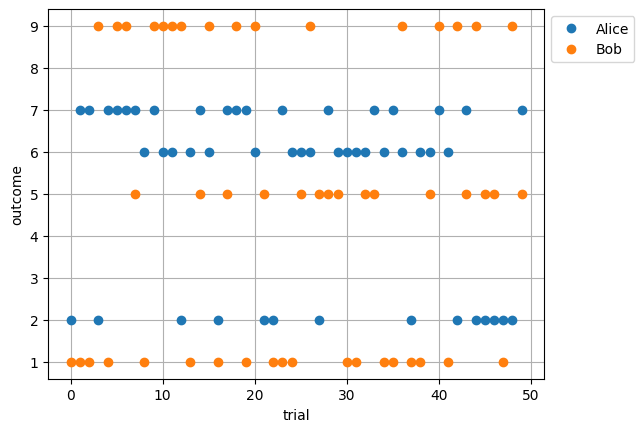

In [5]:
# roll each die 50 times
trials = range(50)

# note there are many ways to simulate this experiment; we will show two methods
# method 1
Alice_rolls = []
for i in trials:
    Alice_rolls.append(Alice.roll())
# method 2
Bob_rolls = [Bob.roll() for i in trials]


# create plot
fig, ax = plt.subplots() # create figure to hold plots
ax.plot(trials, Alice_rolls, 'o', label='Alice') # plot Alice's rolls
ax.plot(trials, Bob_rolls, 'o', label='Bob') # plot Bob's rolls

# label the plots
plt.xlabel('trial')
plt.ylabel('outcome')
plt.grid()
plt.legend(bbox_to_anchor = (1,1))
plt.show()

The following code rolls Alice's die 10,000 times, and computes the relative frequency of each of the three outcomes. Note that the resulting probabilities are all close to 1/3.

In [6]:
total = 10000 # total number of times to roll the die

# roll the die "total" times
trials = range(total)
rolls = [Alice.roll() for i in trials]

# the total number of outcomes is the number of faces with different dots
number_of_outcomes = np.size(Alice.dots)

# for each outcome
for i in range(number_of_outcomes):
    # count the number of times the outcome occurs
    count = np.sum( np.equal( rolls, Alice.dots[i] ) )
    # calculate the relative frequency
    rf = count/total
    # print result
    print(f'The relative frequency of the outcome {Alice.dots[i]} is {rf}.')


The relative frequency of the outcome 2 is 0.3392.
The relative frequency of the outcome 6 is 0.3316.
The relative frequency of the outcome 7 is 0.3292.


### Part a (8 points) : Convergence of relative frequency
Generate plots of the relative frequencies of the three outcomes of Alice's die versus the number of trials, which ranges from 1 to 5,000. The number of trials should be on the x-axis and the relative frequency on the y-axis.

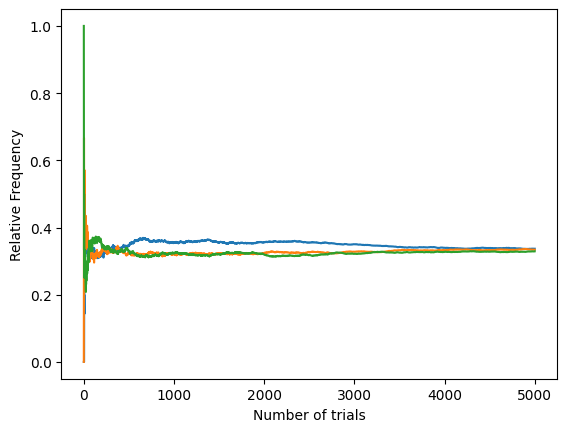

In [7]:
total = 5000 # total number of times to roll the die

# roll the die "total" times
trials = range(total)
rolls = [Alice.roll() for i in trials]

# the total number of outcomes is the number of faces with different dots
number_of_outcomes = np.size(Alice.dots)

# create figure
fig, ax = plt.subplots()

# put your code below and display the result after running your code
# ====================================================================
dat = np.zeros((3,5000))
for i in trials:
 for j in range(number_of_outcomes):
    # count the number of times the outcome occurs

    count = np.sum( np.equal( rolls[:i+1], Alice.dots[j] ) )
    # calculate the relative frequency
    rf = count/(i+1)
    dat[j,i]=rf
    # print result
for j in range(number_of_outcomes):
  ax.plot(range(1,total+1),dat[j])
ax.set_xlabel('Number of trials')
ax.set_ylabel('Relative Frequency')

plt.show()

### Part b (6 points) : Play the game repeatedly.

Play the game 10,000 times and calculate the relative frequency that Alice wins.

In [8]:
total = 10000 # total number of times to roll the die

# put your code below and display the result after running your code
# ====================================================================
Alice_win = 0


Alice_rolls = np.zeros((total))
for i in range(total):
    Alice_rolls[i] = Alice.roll()

Bob_roll = [Bob.roll() for i in range(total)]
Bob_rolls = np.array(Bob_roll)
Alice_win = np.sum(Alice_rolls > Bob_rolls)


rf_wins = Alice_win / total
print(rf_wins)

0.5628


#### Question : Who is more likely to win this game, Alice or Bob? Explain briefly.

#### Answer :Alice is more likely to win this game.Note that there are 9 Combination of results possible. In 5 out of 9 combination Alice wins, hence more likely to win.


### Part c (6 points) : Play the game with two die rolls.

Now assume that Alice and Bob both get two rolls of the die per game and add the two outcomes. The winner is whoever's sum is larger.

Simulate this game 10,000 times and compute the relative frequency that Alice wins.

In [9]:
total = 10000 # total number of times to roll the die

# put your code below and display the result after running your code
# ====================================================================
Alice_win = 0


Alice_rolls = np.zeros((total))
for i in range(total):
    Alice_rolls[i] = Alice.roll()+Alice.roll()

Bob_roll = [Bob.roll()+Bob.roll() for i in range(total)]
Bob_rolls = np.array(Bob_roll)
Alice_win = np.sum(Alice_rolls > Bob_rolls)


rf_wins = Alice_win / total
print(rf_wins)

0.45


#### Question : Who is more likely to win this game, Alice or Bob? Explain briefly.

#### Answer :Bob. In this case there are 81 combination.Out of them bob win in 42 combination and alice wins in 37 and ties in other.

## Part 2: Conditional Probabilities

### Objectives:

- To compute the relative frequency of two events occurring at the same time.
- To compute the relative frequency of one event occurs given that another event has also occurred.
- To be familiar with properties of the relative frequency.

The file “Ex1_Rainfall2021.xlsx”, which is extracted from The Hong Kong Observatory https://www.hko.gov.hk/en/wxinfo/pastwx/mws/mws.htm, stores the rainfall in Hong Kong in 2021. Each element in the column “Rainfall” in the file “Ex1_Rainfall2021.xlsx” indicates the rainfall on a day. A positive value indicates it rained on that day, while a 0 indicates it did not rain on that day. One may wonder if season information indicates whether a day is rainy or not. For this, the column “Seasons” stores the season labels.


Download the file "Ex1_Rainfall2021.xlsx" from the course website to complete the following parts.

We recommend you to use the pandas data analysis package in python to do the lab. In particular, you should find the groupby and count functions provided by pandas useful. More information about the pandas data analysis package can be found from here:

https://pandas.pydata.org/pandas-docs/stable/index.html

However, you are free to do the question using any methods or functions that you like.

We will first load the datafile and look at the first few lines. Do not change the code below.

In [10]:
# load pandas, a data analysis package
import pandas as pd

# read the data file and show the first few entries
data = pd.read_excel('Ex1_Rainfall2021.xlsx',index_col='Index')
data.head()

,Date,Season,Rainfall
Index,,,
1,2021-01-01,winter,0.0
2,2021-01-02,winter,0.0
3,2021-01-03,winter,0.0
4,2021-01-04,winter,0.0
5,2021-01-05,winter,0.0


From the data, let us find the relative frequency that a day is rainy, and the relative frequency of its complement (i.e. a day is not rainy). In other words, we will count the number of days whose rainfall is greater than 0 (or less than or equal to 0) and divide by the total number of days in the dataset.

In [11]:
# add a new column called "Rainy" which is True if the Rainfall value is positive and False otherwise
data['Rainy'] = (data['Rainfall'] > 0)

# count how many days in the year it rained and how many days it did not
# we can use the groupby command to separates the data by whether it rained
# ['Rainy'] selects only the 'Rainy' column
# "count()" counts how many cells in the column have valid entries
n_rain = data.groupby('Rainy')['Rainy'].count()

# total number of days
n = sum(n_rain)

# relative frequence that a day is rainy
p_rain = n_rain / n

print(f'The number of the days whose rainfall is greater than 0 (or less than or equal to 0) is\n')
print(n_rain)

print(f'\nThe total number of days is {n}')

print(f'\nThe relative frequency that a day is rainy, and the relative frequency of its complement are\n')
print(p_rain)

The number of the days whose rainfall is greater than 0 (or less than or equal to 0) is

Rainy
False    233
True     132
Name: Rainy, dtype: int64

The total number of days is 365

The relative frequency that a day is rainy, and the relative frequency of its complement are

Rainy
False    0.638356
True     0.361644
Name: Rainy, dtype: float64


### Part a (7 points)
Find the relative frequencies that a day is a fall day, a spring day, a summer day and a winter day. In other words, count the number of days in each season and divide by the total number of days in the dataset.

In [12]:
# calculate the number of days in each season, and then
# calculate the relative frequencies that a day is fall, spring, summer and winter

# put your code below and display the result after running your code
# =====================================================================
n_rain = data.groupby('Season')['Season'].count()
print(n_rain)
rf_fall = n_rain['fall']/sum(n_rain)
rf_spring = n_rain['spring']/sum(n_rain)
rf_winter= n_rain['winter']/sum(n_rain)
rf_summer = n_rain['summer']/sum(n_rain)
print(rf_fall,rf_spring,rf_winter,rf_summer)

Season
fall      91
spring    92
summer    92
winter    90
Name: Season, dtype: int64
0.2493150684931507 0.25205479452054796 0.2465753424657534 0.25205479452054796


##Part b (7 points)
Find the relative frequencies that a day is a fall rainy day, a spring rainy day, a summer rainy day, and a winter rainy day.

In [13]:
# group by season and sum the boolean entries of "Rainy"

# put your code below and display the result after running your code
# =====================================================================
n_rains = data.groupby('Season')['Rainy'].sum()

rf_falls = n_rains['fall']/sum(n_rain)
rf_springs = n_rains['spring']/sum(n_rain)
rf_winters= n_rains['winter']/sum(n_rain)
rf_summers = n_rains['summer']/sum(n_rain)
print(rf_falls,rf_springs,rf_winters,rf_summers)

0.0821917808219178 0.07945205479452055 0.03287671232876712 0.16712328767123288


### Part c (6 points)

Find the following values:

- The relative frequency that a day is rainy given that the day is a fall day.
- The relative frequency that a day is rainy given that the day is a spring day.
- The relative frequency that a day is rainy given that the day is a summer day.
- The relative frequency that a day is rainy given that the day is a winter day.

In [14]:
# put your code below and display the result after running your code
# =====================================================================
fall_rf = n_rains['fall']/n_rain['fall']
spring_rf = n_rains['spring']/n_rain['spring']
winter_rf = n_rains['winter']/n_rain['winter']
summer_rf = n_rains['summer']/n_rain['summer']
print(fall_rf,spring_rf,summer_rf,winter_rf)

0.32967032967032966 0.31521739130434784 0.6630434782608695 0.13333333333333333
